In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
import librosa
import librosa.display

📥 Step 2: Load an Audio File

In [9]:
audio_path = "../sound effects/gun-shot-350315.mp3"
audio_path1 = "../sound effects/crash-1-154890.mp3"
y, sr = librosa.load(audio_path, sr=22050)
y1, sr1 = librosa.load(audio_path1, sr=22050)  # load audio with 22.05kHz sample rate


🎨 Step 3: Generate Mel Spectrogram and Plot

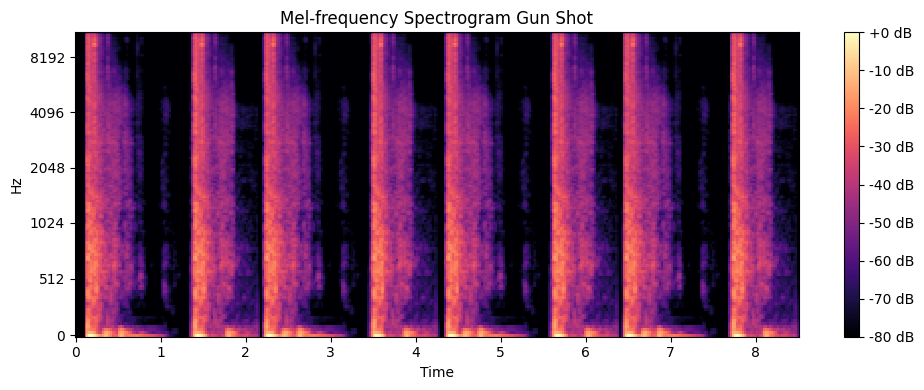

In [12]:
# Generate Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_DB = librosa.power_to_db(S, ref=np.max)

# Plot spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency Spectrogram Gun Shot')
plt.tight_layout()
# Save the Mel Spectrogram as an image
plt.savefig('spectrogram_gun1.png', dpi=300, bbox_inches='tight')
plt.show()

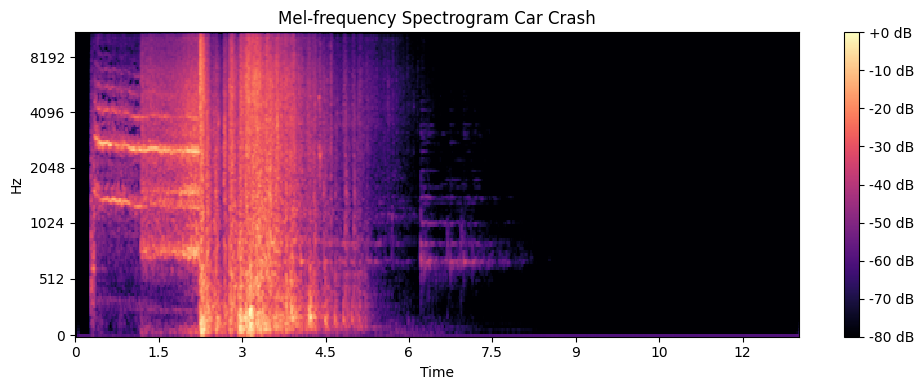

In [13]:
# Generate Mel Spectrogram
S = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=128)
S_DB = librosa.power_to_db(S, ref=np.max)

# Plot spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_DB, sr=sr1, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency Spectrogram Car Crash')
plt.tight_layout()
# Save the Mel Spectrogram as an image
plt.savefig('spectrogram_crash1.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
input_folder = '../sound effects'
output_folder = '../spectogram dataset'

os.makedirs(output_folder, exist_ok=True)
# mp3 or wav files
for filename in os.listdir(input_folder):
    if filename.endswith('.mp3' or filename.endswith('.wav')):
        filepath = os.path.join(input_folder, filename)
        y, sr = librosa.load(filepath, sr=22050)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_DB = librosa.power_to_db(S, ref=np.max)

        plt.figure(figsize=(3, 3))
        librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
        plt.axis('off')
        output_path = os.path.join(output_folder, filename.replace('.mp3', '.png'))
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
        plt.close()